In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)


In [ ]:
X_TRAIN_PATH = r"C:\Users\tej\OneDrive\Desktop\ML-2.1\data\X_train_processed1.csv"
X_TEST_PATH  = r"C:\Users\tej\OneDrive\Desktop\ML-2.1\data\X_test_processed1.csv"

X_train = pd.read_csv(X_TRAIN_PATH)
X_test = pd.read_csv(X_TEST_PATH)

y_train = X_train['CGPA_Tier']
y_test = X_test['CGPA_Tier']
X_train1 = X_train.drop(columns=['CGPA_Tier'])
X_test1 = X_test.drop(columns=['CGPA_Tier'])

if isinstance(y_train, pd.DataFrame) and y_train.shape[1] == 1:
    y_train = y_train.iloc[:, 0]
if isinstance(y_test, pd.DataFrame) and y_test.shape[1] == 1:
    y_test = y_test.iloc[:, 0]

categorical_columns = X_train1.select_dtypes(exclude="number").columns
X_train1 = pd.get_dummies(
    X_train1, columns=categorical_columns, dtype=float
)
X_test1 = pd.get_dummies(
    X_test1, columns=categorical_columns, dtype=float
)
X_test1 = X_test1.reindex(columns=X_train1.columns, fill_value=0)

print("X_train1:", X_train1.shape)
print("X_test1 :", X_test1.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTarget distribution:")
print(y_train.value_counts().sort_index())

X_train1: (40000, 51)
X_test1 : (10000, 51)
y_train: (40000,)
y_test : (10000,)

Target distribution:
CGPA_Tier
High    13402
Low     13426
Mid     13172
Name: count, dtype: int64


In [ ]:
print("Missing values in X_train:", X_train1.isna().sum().sum())
print("Missing values in X_test :", X_test1.isna().sum().sum())

print("\nFeature columns:")
print(list(X_train1.columns))

print("\nTarget classes:")
print(sorted(pd.Series(y_train).unique()))


Missing values in X_train: 0
Missing values in X_test : 0

Feature columns:
['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'IsAnomaly', 'Salary Package', 'Workshops_missing', 'AptitudeTestScore_missing', 'SoftSkillsRating_missing', 'CodingTestScore_missing', 'MockInterviewScore_missing', 'CollegeTier', 'Gender_Male', 'City_Bangalore', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kochi', 'City_Kolkata', 'City_Mumbai', 'City_Pune', 'Stream_Civil', 'Stream_ECE', 'Stream_EE', 'Stream_IT', 'Stream_Mechanical', 'Specialisation_DataScience', 'Specialisation_Embedded', 'Specialisation_Networking', 'Hostel_Yes', 'HistoryOfBacklogs_Yes']

Target classes:
['High', 'Low', 'Mid']


In [ ]:
print("Categorical columns in X_train1:")
print(X_train1.select_dtypes(include="object").columns)

Categorical columns in X_train1:
Index(['CollegeTier'], dtype='str')


C:\Users\tej\AppData\Local\Temp\ipykernel_25960\1929029550.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X_train1.select_dtypes(include="object").columns)


In [ ]:
X_train1.columns

Index(['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4',
       'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA',
       'AttendancePercent', 'Internships', 'Projects', 'Workshops',
       'Certifications', 'Publications', 'AptitudeTestScore',
       'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore',
       'ExtraCurricular', 'IsAnomaly', 'Salary Package', 'Workshops_missing',
       'AptitudeTestScore_missing', 'SoftSkillsRating_missing',
       'CodingTestScore_missing', 'MockInterviewScore_missing', 'CollegeTier',
       'Gender_Male', 'City_Bangalore', 'City_Chennai', 'City_Delhi',
       'City_Hyderabad', 'City_Jaipur', 'City_Kochi', 'City_Kolkata',
       'City_Mumbai', 'City_Pune', 'Stream_Civil', 'Stream_ECE', 'Stream_EE',
       'Stream_IT', 'Stream_Mechanical', 'Specialisation_DataScience',
       'Specialisation_Embedded', 'Specialisation_Networking', 'Hostel_Yes',
       'HistoryOfBacklogs_Yes'],
      dtype='str')

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

model.fit(X_train1, y_train)

print("Model trained successfully.")
print("Classes:", model.classes_)

Model trained successfully.
Classes: ['High' 'Low' 'Mid']


In [ ]:
def evaluate_classifier(model, X, y, dataset_name="Dataset"):
    y_pred = model.predict(X)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(
        y, y_pred, average="weighted", zero_division=0
    )
    recall = recall_score(
        y, y_pred, average="weighted", zero_division=0
    )
    f1 = f1_score(
        y, y_pred, average="weighted", zero_division=0
    )

    print(f"===== {dataset_name} =====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y, y_pred, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(y, y_pred))

    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision_weighted": precision,
        "Recall_weighted": recall,
        "F1_weighted": f1
    }


In [ ]:
train_results = evaluate_classifier(
    model, X_train1, y_train, "Training"
)

test_results = evaluate_classifier(
    model, X_test1, y_test, "Test"
)

evaluation_df = pd.DataFrame([
    train_results,
    test_results
])

display(evaluation_df)


===== Training =====
Accuracy : 0.9843
Precision: 0.9844
Recall   : 0.9843
F1-score : 0.9844

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00     13402
         Low       0.98      0.98      0.98     13426
         Mid       0.98      0.98      0.98     13172

    accuracy                           0.98     40000
   macro avg       0.98      0.98      0.98     40000
weighted avg       0.98      0.98      0.98     40000

Confusion Matrix:
[[13352     0    50]
 [    0 13158   268]
 [   28   280 12864]]
===== Test =====
Accuracy : 0.9817
Precision: 0.9817
Recall   : 0.9817
F1-score : 0.9817

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      3279
         Low       0.97      0.98      0.98      3307
         Mid       0.98      0.97      0.97      3414

    accuracy                           0.98     10000
   macro avg       0.98      0.98  

,Dataset,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
0,Training,0.98435,0.984361,0.98435,0.984355
1,Test,0.98170,0.981729,0.98170,0.981703


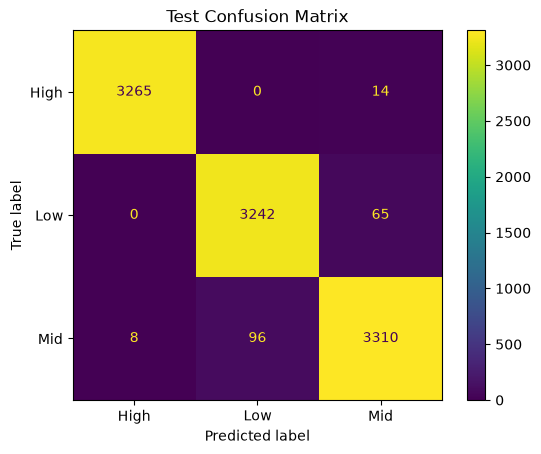

In [ ]:
y_test_pred = model.predict(X_test1)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    values_format="d"
)

plt.title("Test Confusion Matrix")
plt.show()


In [ ]:
# Binary: one coefficient per feature.
# Multinomial: one coefficient row per class.

if model.coef_.shape[0] == 1:
    coefficient_df = pd.DataFrame({
        "Feature": X_train1.columns,
        "Coefficient": model.coef_[0]
    })
    display(coefficient_df)

else:
    coefficient_df = pd.DataFrame(
        model.coef_,
        index=[f"Class={c}" for c in model.classes_],
        columns=X_train1.columns
    )
    display(coefficient_df)


,StudentID,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,...,Stream_IT,Stream_Mechanical,Specialisation_DataScience,Specialisation_Embedded,Specialisation_Networking,Hostel_Yes,HistoryOfBacklogs_Yes,CollegeTier_Tier1,CollegeTier_Tier2,CollegeTier_Tier3
Class=High,0.040106,2.817933,2.508205,2.816972,2.800006,2.821493,2.833235,2.745698,3.004810,2.213495,...,0.235997,0.041509,0.134367,0.095504,0.036282,-0.059099,1.031484,-0.559904,-0.931057,-0.831175
Class=Low,-0.036231,-3.026400,-2.659933,-2.898008,-2.883461,-2.943102,-3.174920,-3.087861,-3.318502,-2.228529,...,-0.157407,0.046598,0.008696,0.045526,0.045401,0.006769,-0.783574,-1.281158,-1.069817,-1.135777
Class=Mid,-0.003875,0.208467,0.151728,0.081036,0.083455,0.121609,0.341685,0.342164,0.313692,0.015034,...,-0.078590,-0.088107,-0.143064,-0.141030,-0.081684,0.052330,-0.247910,1.841061,2.000873,1.966952


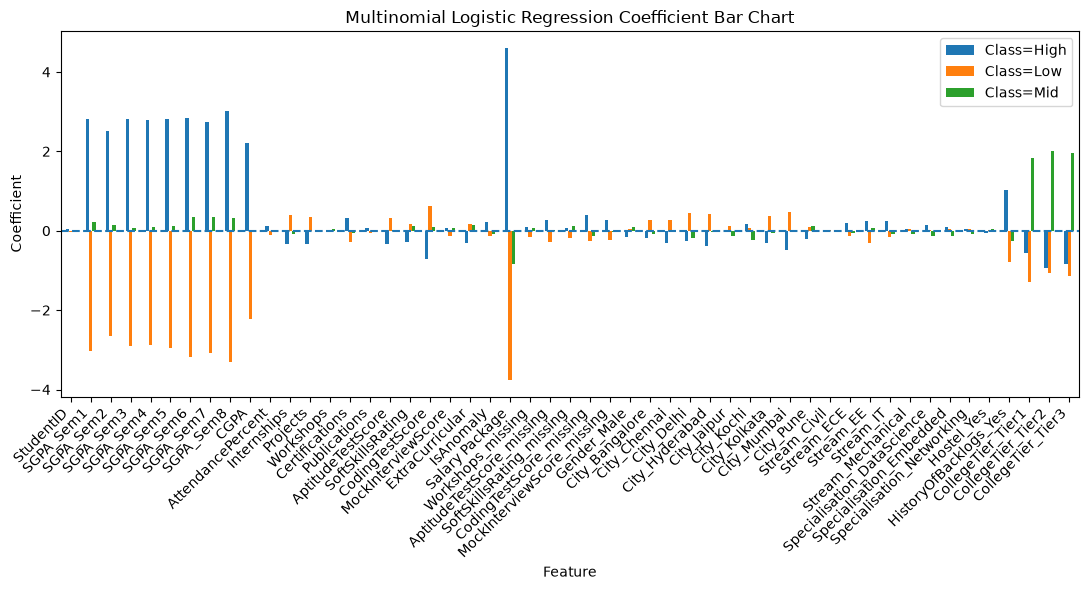

In [ ]:
if model.coef_.shape[0] == 1:

    plot_df = pd.DataFrame({
        "Feature": X_train1.columns,
        "Coefficient": model.coef_[0]
    }).sort_values("Coefficient")

    plt.figure(figsize=(9, 6))
    plt.barh(plot_df["Feature"], plot_df["Coefficient"])
    plt.axvline(0, linestyle="--")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title("Logistic Regression Coefficient Bar Chart")
    plt.tight_layout()
    plt.show()

else:
    coefficient_plot_df = coefficient_df.T

    ax = coefficient_plot_df.plot(
        kind="bar",
        figsize=(11, 6)
    )

    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Coefficient")
    ax.set_title("Multinomial Logistic Regression Coefficient Bar Chart")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
